In [5]:
#week 2

import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
import math

td = pd.read_csv("Titanic.csv")
td.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("# of passengers in orginal data:" + str(len(td.index)))

# of passengers in orginal data:891


Analyzing Data

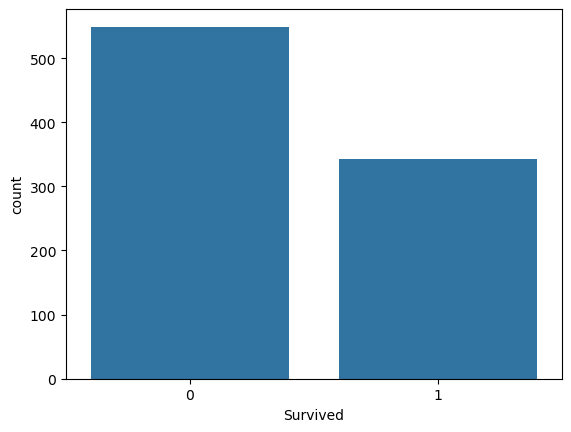

In [8]:
sns.countplot(x="Survived", data =td)
plt.show()

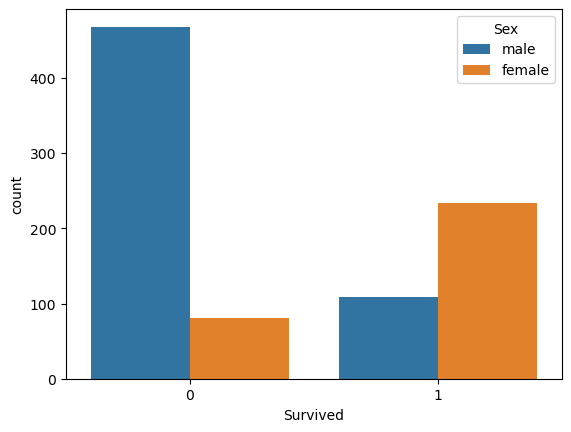

In [9]:
sns.countplot(x="Survived", hue="Sex", data=td)
plt.show()

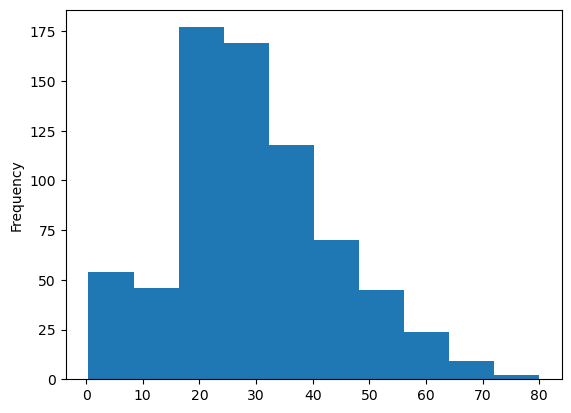

In [10]:
td['Age'].plot.hist()
plt.show()

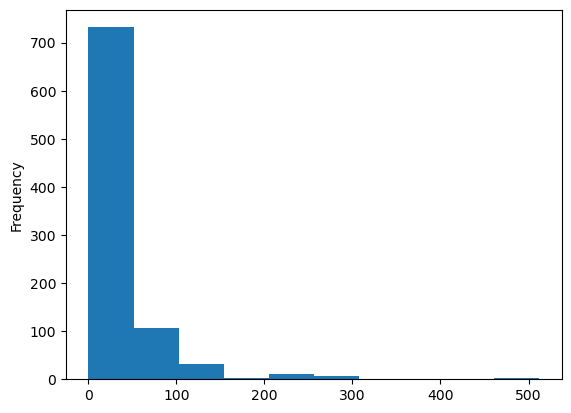

In [11]:
td['Fare'].plot.hist()
plt.show()

In [12]:
td.info()






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


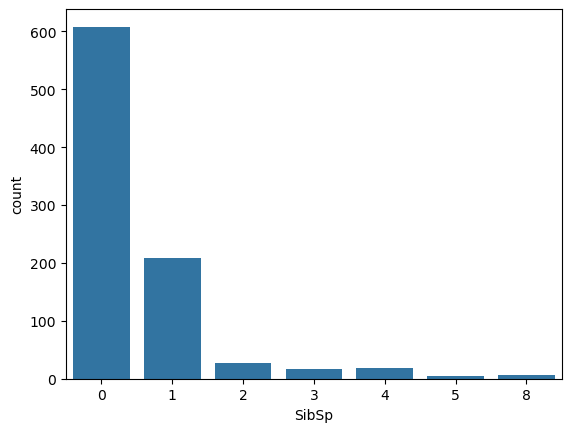

In [14]:
sns.countplot(x="SibSp",data=td)
plt.show()

### Data Wrangling

In [21]:
td.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [25]:

td.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
td.drop('Cabin', axis = 1, inplace=True)
td.dropna(inplace= True)

In [33]:
print(td.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


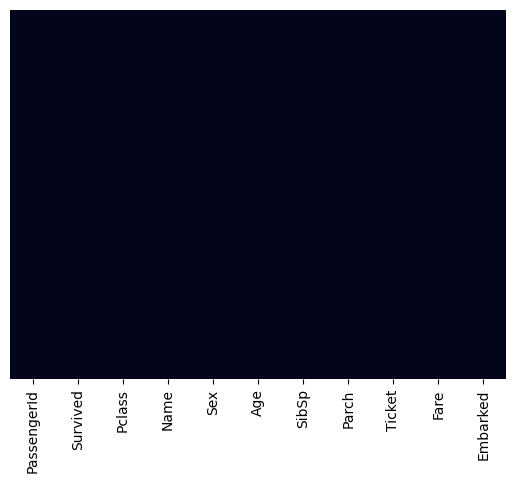

In [43]:
sns.heatmap(td.isnull(), yticklabels=False, cbar=False)
plt.show()

In [45]:
td.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [47]:
td.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [53]:
sex= pd.get_dummies(td['Sex'] ,drop_first = True)
sex.head()

,male
0,True
1,False
2,False
3,False
4,True


In [57]:
embark= pd.get_dummies(td['Embarked'],drop_first = True)
embark.head(5)

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [59]:
pc= pd.get_dummies(td['Pclass'],drop_first = True)
embark.head(5)

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [67]:
td = pd.concat([td,sex,embark,pc],axis=1)
td.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,male,Q,S,2,3,male,Q,S,2,3
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,True,False,True,False,True,True,False,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,False,False,True,False,True,False,False,True,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,False,False,True,False,False,False,False,True,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,True,False,True,False,True,True,False,True,False,True


In [111]:
td.drop(columns=['Name','Sex','PassengerId','Embarked','Ticket'], errors='ignore')
td.head()

,Survived,Pclass,Name,Age,SibSp,Parch,Fare,male,Q,S,2,3,male,Q,S,2,3
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,True,False,True,False,True,True,False,True,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,False,False,False,False,False,False,False,False,False,False
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,False,False,True,False,True,False,False,True,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,False,False,True,False,False,False,False,True,False,False
4,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,True,False,True,False,True,True,False,True,False,True


# Training Data

In [114]:
X= td.drop('Survived',axis =1)
Y = td['Survived']

In [118]:
from sklearn.model_selection import train_test_split

In [130]:
X_train,X_test, y_train, y_test = train_test_split(X,Y,test_size=0.33,random_state = 42)

In [146]:
from sklearn.linear_model import LogisticRegression

In [168]:
td = td.drop(columns=['Name'], errors='ignore')


In [176]:
# 1. Drop irrelevant text columns
td = td.drop(columns=['Name','Ticket','Cabin'], errors='ignore')

# 2. Handle categorical variables (Sex, Embarked, etc.)
td = pd.get_dummies(td, drop_first=True)

# 3. Handle missing values (fill with median or mode)
td = td.fillna(td.median(numeric_only=True))

# 4. Define features (X) and target (y)
X = td.drop('Survived', axis=1)
y = td['Survived']

# 5. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. Fit logistic regression
logmodel = LogisticRegression(max_iter=200)



X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

logmodel.fit(X_train, y_train)

C:\Users\HETANSHI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [178]:
pre = logmodel.predict(X_test)

In [182]:
from sklearn.metrics import classification_report
classification_report(y_test,pre)

'              precision    recall  f1-score   support\n\n           0       0.79      0.86      0.82       122\n           1       0.79      0.70      0.74        92\n\n    accuracy                           0.79       214\n   macro avg       0.79      0.78      0.78       214\nweighted avg       0.79      0.79      0.79       214\n'

In [184]:
from sklearn.metrics import confusion_matrix

In [186]:
confusion_matrix(y_test,pre)

array([[105,  17],
       [ 28,  64]], dtype=int64)

In [188]:
from sklearn.metrics import accuracy_score

In [190]:
accuracy_score(y_test,pre)

0.7897196261682243